In [20]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from scipy.stats import loguniform, randint


df_train = pd.read_csv('ram.csv')
df_test = pd.read_csv('testram.csv')


def convert_memory(mem_str):
    mem_str = str(mem_str).lower()
    if 'g' in mem_str:
        return float(mem_str.replace('g', '')) * 1024
    elif 'm' in mem_str:
        return float(mem_str.replace('m', ''))
    return float(mem_str)

def preprocess(df):
    df = df.copy()

    df['device_write_numeric'] = df['device_write'].str.replace('mb', '').astype(float)
    df['memory_numeric'] = df['memory'].apply(convert_memory)

    df = df[df['Throughput'] != 0]

    # Feature engineering
    df['load_per_cpu'] = df['ArrivalRate'] / (df['cpus'] + 1e-6)
    df['cpu_capacity'] = df['cpus'] * (1 - df['cpuLoad'])
    df['utilization'] = df['ArrivalRate'] / (df['cpu_capacity'] + 1e-6)

    return df

train = preprocess(df_train)
test = preprocess(df_test)


X_cols = [
    'ArrivalRate', 'cpus', 'size', 'cpuLoad',
    'device_write_numeric', 'memory_numeric',
    'load_per_cpu', 'cpu_capacity', 'utilization'
]

X_train = train[X_cols].values
X_test = test[X_cols].values

# Log-transform targets
y_tp_train = np.log1p(train['Throughput'].values)
y_tp_test = np.log1p(test['Throughput'].values)

y_rt_train = np.log1p(train['ResponseTime'].values)
y_rt_test = np.log1p(test['ResponseTime'].values)


def p90_ape(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)
    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100
    return np.percentile(pct_err, 90)

from sklearn.metrics import make_scorer
p90_scorer = make_scorer(p90_ape, greater_is_better=False)


param_dist = {
    'n_estimators': randint(400, 1200),
    'max_depth': randint(4, 10),
    'learning_rate': loguniform(0.01, 0.1),
    'subsample': loguniform(0.6, 1.0),
    'colsample_bytree': loguniform(0.6, 1.0),
    'min_child_weight': randint(1, 10),
    'reg_alpha': loguniform(1e-4, 1),
    'reg_lambda': loguniform(1e-4, 10)
}

def tune(X, y, name):
    print(f"\nTuning {name} (P90 APE)...")

    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=30,
        scoring=p90_scorer,
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search.fit(X, y)

    print("Best params:", search.best_params_)
    print("Best CV P90 APE:", -search.best_score_)

    return search.best_estimator_

model_tp = tune(X_train, y_tp_train, "Throughput")
model_rt = tune(X_train, y_rt_train, "Response Time")


def evaluate(y_true_log, y_pred_log, name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100

    p90 = np.percentile(pct_err, 90)
    mape = np.mean(pct_err) / 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)

    acc_10 = (pct_err <= 10).mean() * 100
    acc_20 = (pct_err <= 20).mean() * 100
    acc_50 = (pct_err <= 50).mean() * 100
    acc_90 = (pct_err <= 90).mean() * 100

    print(f"\n{name} RESULTS")
    print("-" * 40)
    print(f"P90 APE:        {p90:.2f}%  PRIMARY METRIC")
    print(f"MAPE:           {mape*100:.2f}%")
    print(f"SMAPE:          {smape:.4f}")
    print(f"RMSE:           {rmse:.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"R²:             {r2:.4f}")
    print(f"Acc ≤10%:       {acc_10:.2f}%")
    print(f"Acc ≤20%:       {acc_20:.2f}%")
    print(f"Acc ≤50%:       {acc_50:.2f}%")
    print(f"Acc ≤90%:       {acc_90:.2f}%")


evaluate(y_tp_test, model_tp.predict(X_test), "THROUGHPUT")
evaluate(y_rt_test, model_rt.predict(X_test), "RESPONSE TIME")


Tuning Throughput (P90 APE)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.7077068785143116), 'learning_rate': np.float64(0.03302103045515254), 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 512, 'reg_alpha': np.float64(0.00018178958090803957), 'reg_lambda': np.float64(0.001860274657300743), 'subsample': np.float64(0.6806445888880991)}
Best CV P90 APE: 104.88869940460683

Tuning Response Time (P90 APE)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.6102158923676756), 'learning_rate': np.float64(0.022134578078538455), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 1037, 'reg_alpha': np.float64(0.00037982145084532605), 'reg_lambda': np.float64(0.028006820077310226), 'subsample': np.float64(0.9926966840467937)}
Best CV P90 APE: 2623.589597683117

THROUGHPUT RESULTS
----------------------------------------
P90 APE:        51.28%  PRIMARY METRIC
MA

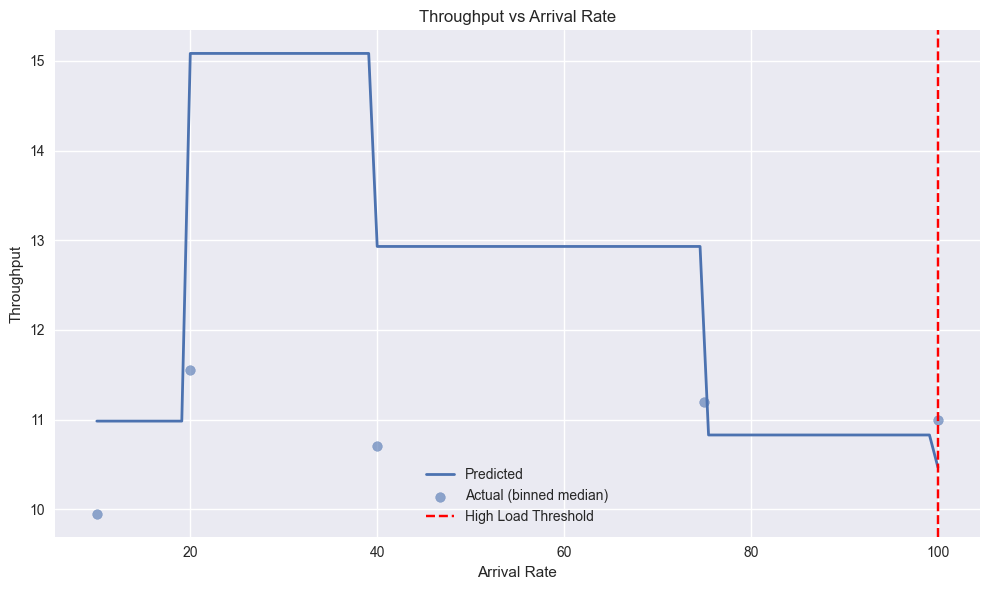

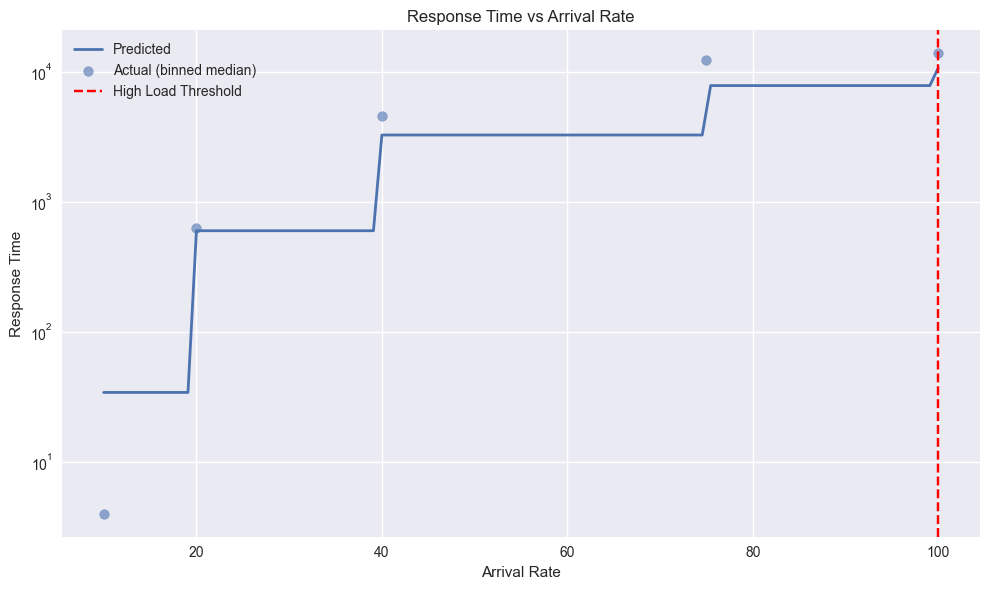

In [21]:
# Make graphs for predicted vs actual for both throughput and response time
# Use training data wrt arrival rate and keep rest of the features fixed at median values to visualize how predictions vary with arrival rate.
"""
Arrival Rate Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


def create_arrival_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    arrival_range = np.linspace(
        df['ArrivalRate'].min(),
        df['ArrivalRate'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['ArrivalRate'] = arrival_range

    return arrival_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin arrival rate to smooth curve
    df['Arrival_bin'] = pd.cut(df['ArrivalRate'], bins=bins)

    grouped = (
        df.groupby('Arrival_bin')[['ArrivalRate', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['ArrivalRate'], grouped


arrival_range, X_sweep = create_arrival_sweep(train, X_cols)
arrival_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Throughput")
plt.title("Throughput vs Arrival Rate")

# Optional: mark high-load region
plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('xgboost_throughput_vs_arrival_rate.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Response Time")
plt.title("Response Time vs Arrival Rate")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('xgboost_response_time_vs_arrival_rate.png', dpi=300)
# plt.show()

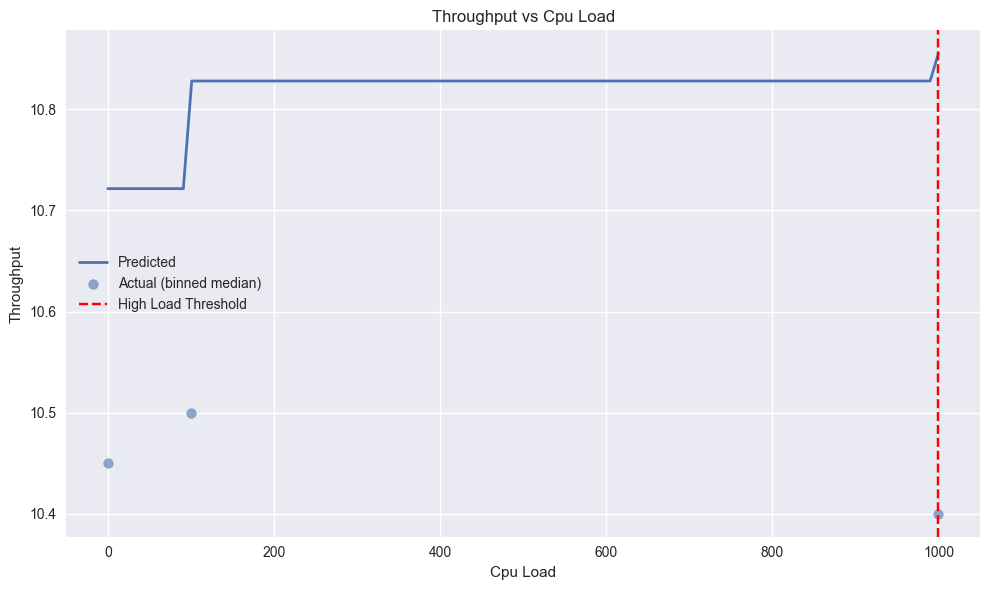

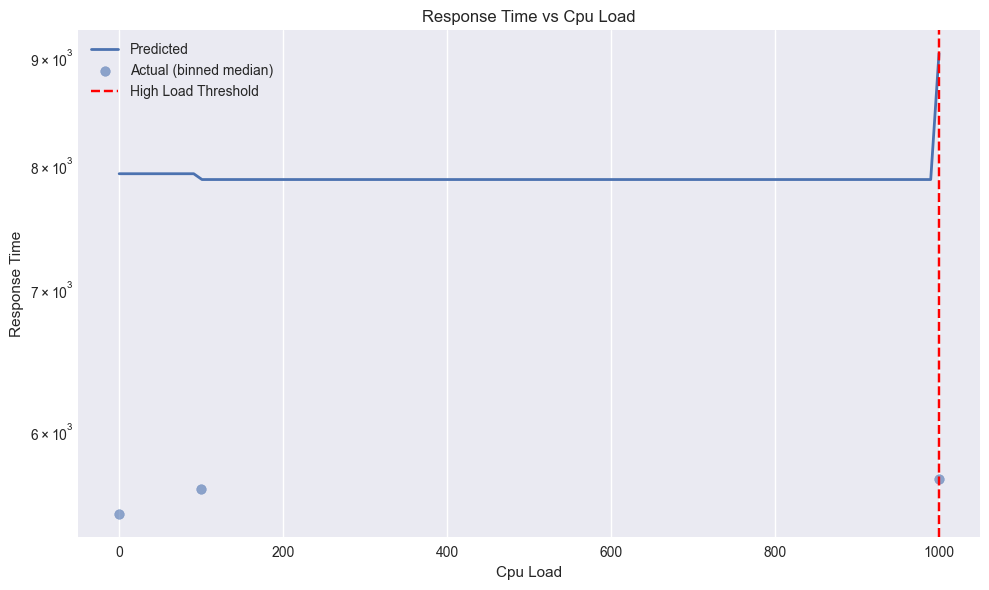

In [22]:
"""
cpu load Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_cpu_load_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    cpu_load_range = np.linspace(
        df['cpuLoad'].min(),
        df['cpuLoad'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['cpuLoad'] = cpu_load_range

    return cpu_load_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin cpu load to smooth curve
    df['cpuLoad_bin'] = pd.cut(df['cpuLoad'], bins=bins)

    grouped = (
        df.groupby('cpuLoad_bin')[['cpuLoad', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['cpuLoad'], grouped


cpu_load_range, X_sweep = create_cpu_load_sweep(train, X_cols)
cpu_load_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    cpu_load_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Cpu Load")
plt.ylabel("Throughput")
plt.title("Throughput vs Cpu Load")

# Optional: mark high-load region
plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('xgboost_throughput_vs_cpu_load.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    cpu_load_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Cpu Load")
plt.ylabel("Response Time")
plt.title("Response Time vs Cpu Load")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('xgboost_response_time_vs_cpu_load.png', dpi=300)

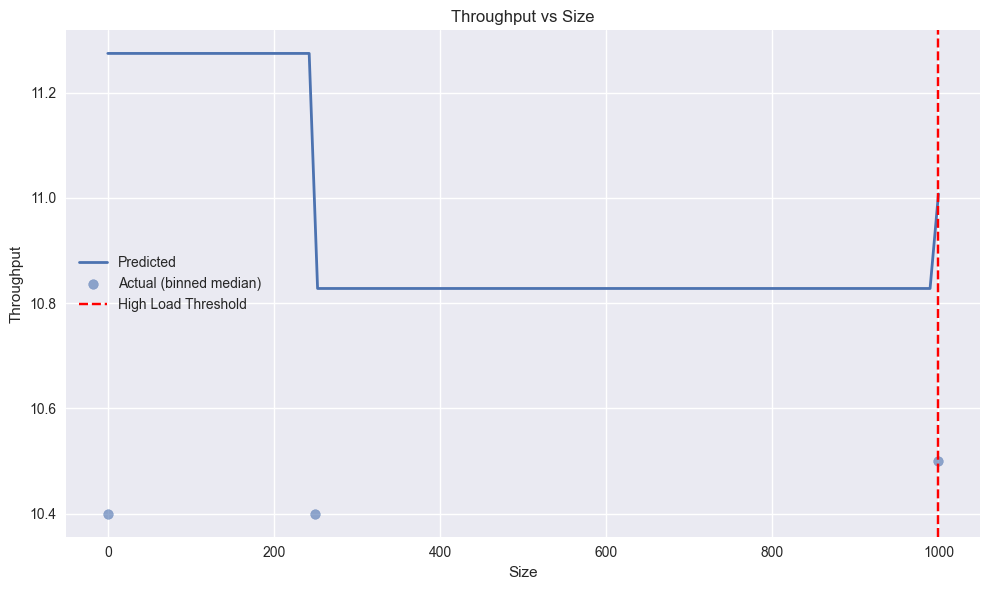

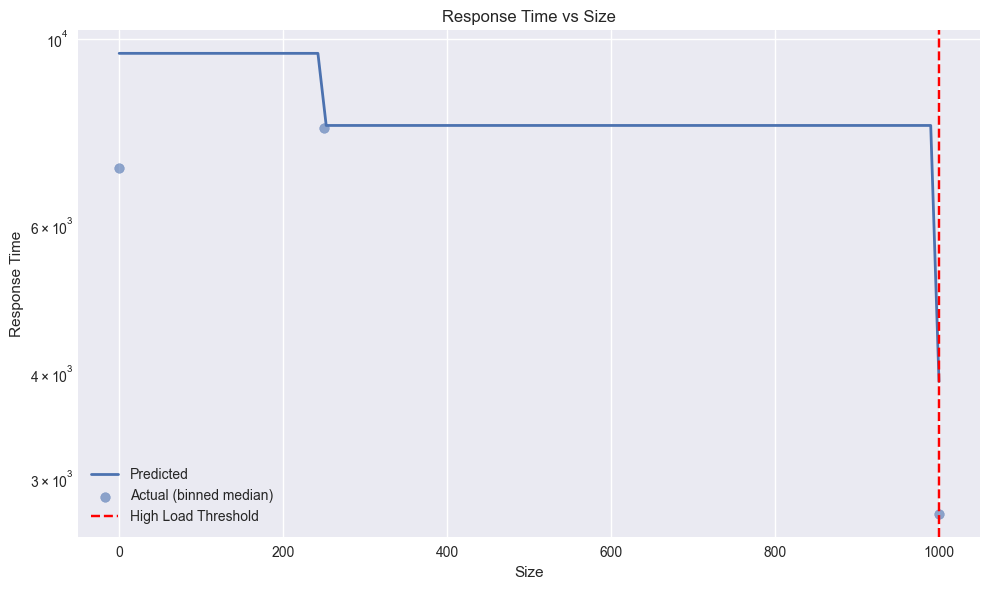

In [23]:
"""
Size Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_size_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    size_range = np.linspace(
        df['size'].min(),
        df['size'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['size'] = size_range

    return size_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin size to smooth curve
    df['Size_bin'] = pd.cut(df['size'], bins=bins)

    grouped = (
        df.groupby('Size_bin')[['size', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['size'], grouped


size_range, X_sweep = create_size_sweep(train, X_cols)
size_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Throughput")
plt.title("Throughput vs Size")

# Optional: mark high-load region
plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('xgboost_throughput_vs_size.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Response Time")
plt.title("Response Time vs Size")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('xgboost_response_time_vs_size.png', dpi=300)